In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df = pd.read_csv('macro_data - Лист1.csv')

In [4]:
df

,Date,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,19.36,0.0,21.97,8.66,0
1,1993,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,17.13,0.0,21.97,8.66,0
2,1994,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,15.96,0.0,21.97,8.66,0
3,1995,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,17.20,0.0,21.97,8.66,0
4,1996,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,20.81,0.0,21.97,8.66,0
5,1997,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,19.31,0.0,21.97,8.66,0
6,1998,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,13.13,0.0,21.97,8.66,0
7,1999,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,18.13,0.0,21.97,8.66,0
8,2000,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,28.85,0.0,22.92,13.15,0
9,2001,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.71,0.0,23.38,8.37,0


In [5]:
df.shape

(34, 22)

In [6]:
df.columns.tolist()

['Date',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [7]:
df.isna().mean() * 100

Date                                            0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule                                     0.0
Expenditure 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Date                                          34 non-null     int64  
 1   Gross National Savings                        34 non-null     float64
 2   Government Debt                               34 non-null     float64
 3   Natural Gas Production                        34 non-null     float64
 4   Iron Ore Production                           34 non-null     float64
 5   Inbound Foreign Direct Investment             34 non-null     float64
 6   Natural Population Growth                     34 non-null     float64
 7   Government Budget Revenues                    34 non-null     float64
 8   Coal Imports                                  34 non-null     float64
 9   Share of Military Expenditures in the Budget  34 non-null     float

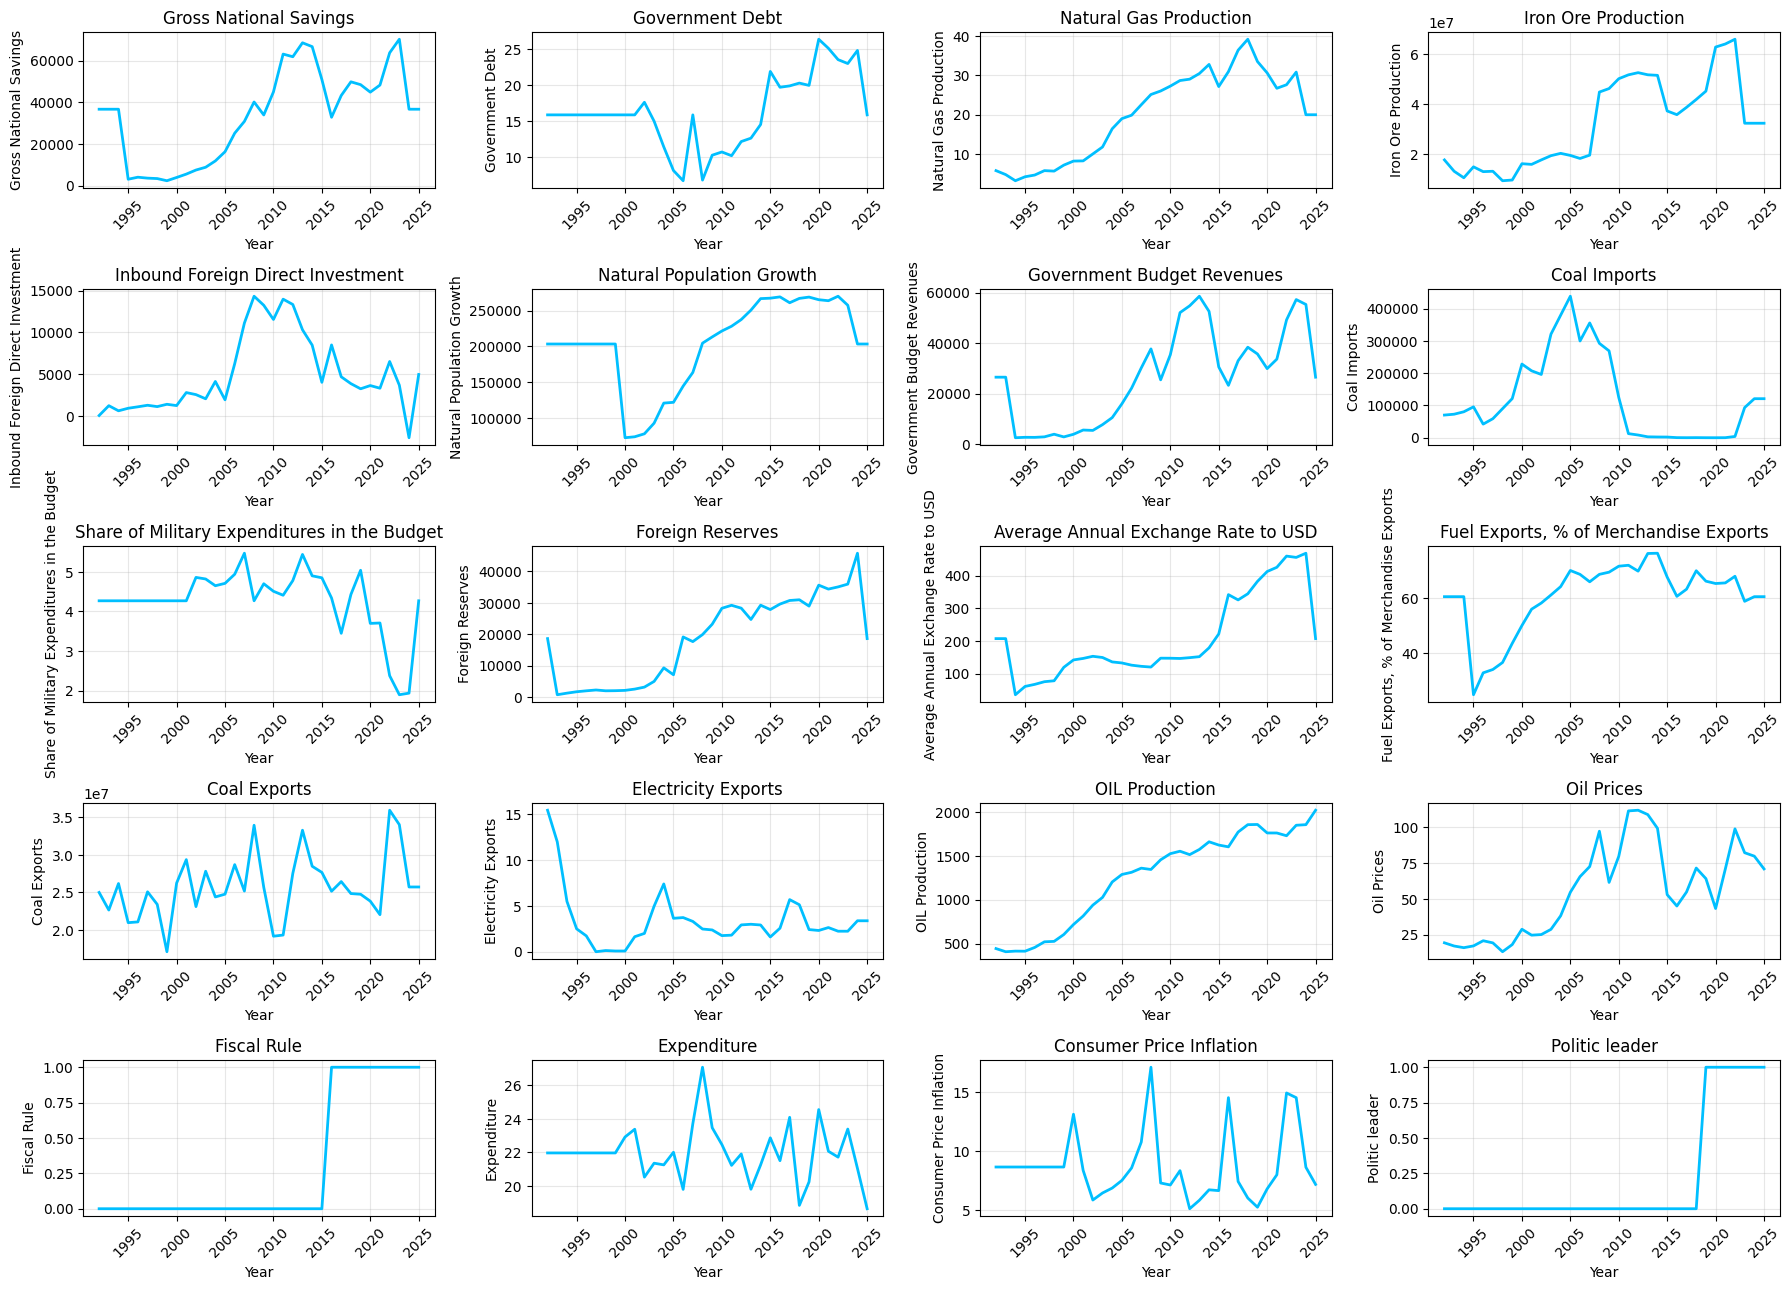

In [13]:
cols = [
    "Gross National Savings",
    "Government Debt",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",
    "Fiscal Rule",
    "Expenditure",
    "Consumer Price Inflation",
    "Politic leader"
]

plt.figure(figsize=(18, 13))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 4, i)
    plt.plot(df["Date"], df[col], color="deepskyblue", linewidth=2)
    plt.grid(alpha=0.3)
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
cols = df.columns
mid = len(cols) // 2

first_half = cols[:mid]
second_half = cols[mid:]

In [28]:
display(df[first_half].describe().round(2))
display(df[second_half].describe().round(2))

,Date,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72
std,9.96,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14
min,1992.00,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00
25%,2000.25,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75
50%,2008.50,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00
75%,2016.75,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25
max,2025.00,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00


,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,3.43,207.42,60.61,25723621.19,3.38,1257.72,55.45,0.29,21.97,8.66,0.21
std,5.89,128.28,12.54,4220621.13,3.12,533.55,31.75,0.46,1.62,2.93,0.41
min,-12.60,35.54,24.99,17097980.00,0.00,408.00,13.13,0.00,18.65,5.11,0.00
25%,1.20,127.79,59.35,23510567.50,1.86,742.25,24.82,0.00,21.26,6.82,0.00
50%,4.15,149.35,63.80,25170530.50,2.54,1407.50,54.78,0.00,21.97,8.36,0.00
75%,7.38,299.93,68.72,27631718.00,3.58,1712.07,78.02,1.00,22.77,8.66,0.00
max,13.50,468.96,76.39,35948140.00,15.45,2019.86,112.01,1.00,27.07,17.15,1.00


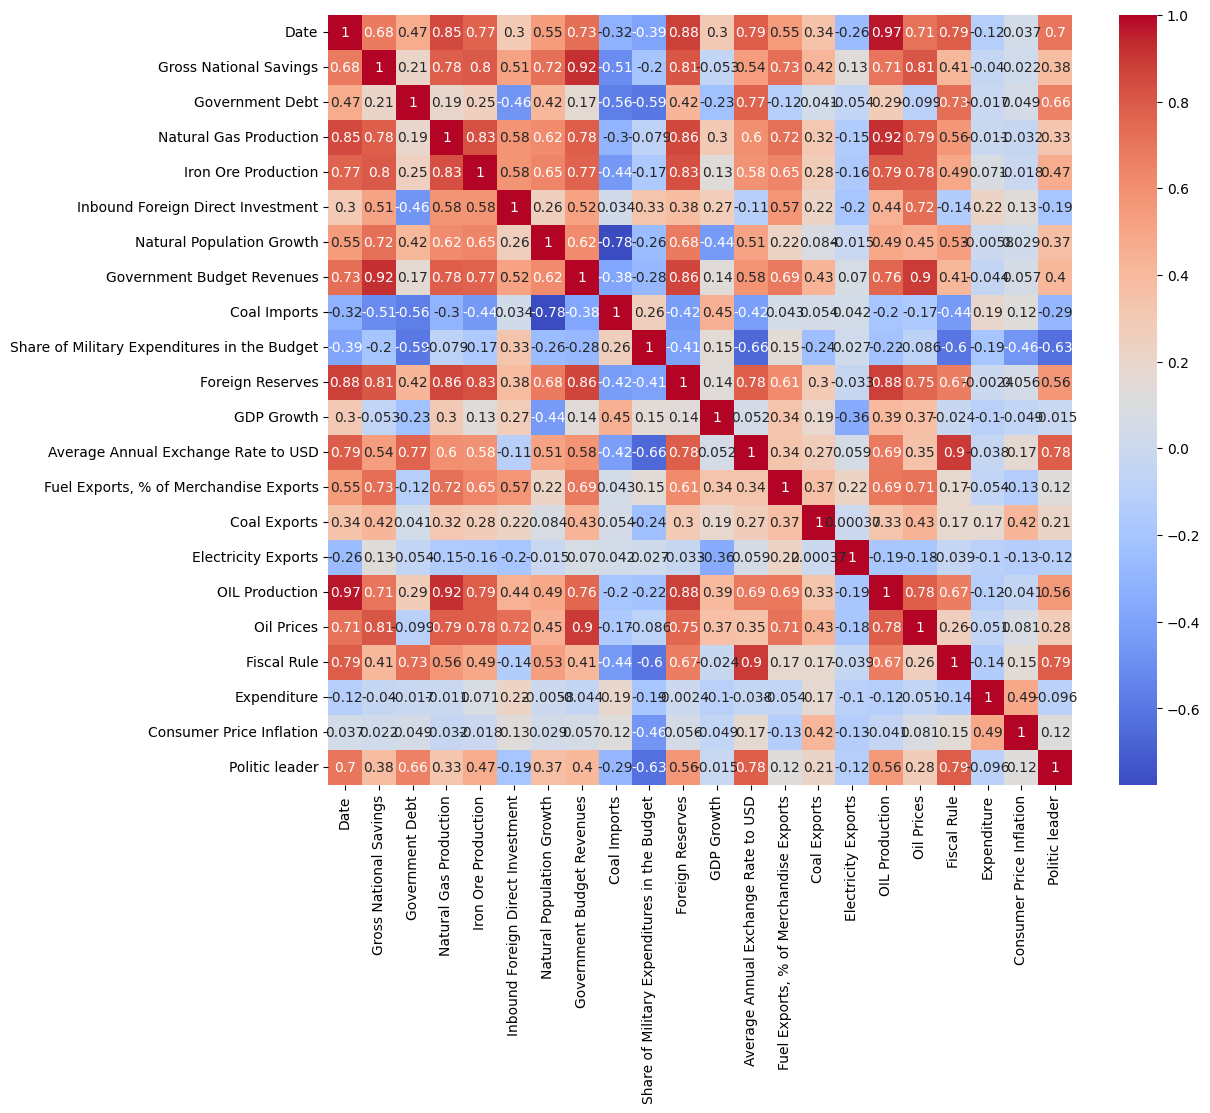

In [29]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [30]:
y = df["GDP Growth"]

X = df[[
    
    "Gross National Savings",
    "Government Debt",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",      
    "Fiscal Rule",
    "Expenditure",
    "Consumer Price Inflation",
    "Politic leader"
]]

In [31]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP Growth   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     7.615
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           0.000270
Time:                        22:54:59   Log-Likelihood:                -64.780
No. Observations:                  34   AIC:                             171.6
Df Residuals:                      13   BIC:                             203.6
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           14.0383     17.106      0.821      0.427     -22.918      50.994
Gross National Savings                          -0.0004      0.000     -1.823      0.091      -0.001     6.6e-05
Government Debt                                  0.1150      0.360      0.320      0.754      -0.663       0.893
Natural Gas Production                           0.8982      0.460      1.951      0.073      -0.097       1.893
Iron Ore Production                          -2.973e-07   1.18e-07     -2.514      0.026   -5.53e-07   -4.18e-08
Inbound Foreign Direct Investment                0.0003      0.000      0.980      0.345      -0.000       0.001
Natural Population Growth                    -7.408e-05   2.31e-05     -3.205      0.007      -0.000   -2.41e-05
Government Budget Revenues                      -0.0003      0.000     -1.463      0.167      -0.001       0.000
Coal Imports                                 -3.975e-05   1.54e-05     -2.587      0.023   -7.29e-05   -6.56e-06
Share of Military Expenditures in the Budget    -2.0828      2.081     -1.001      0.335      -6.578       2.412
Foreign Reserves                             -9.928e-05      0.000     -0.672      0.514      -0.000       0.000
Average Annual Exchange Rate to USD              0.0371      0.032      1.144      0.273      -0.033       0.107
Fuel Exports, % of Merchandise Exports           0.1281      0.187      0.686      0.505      -0.275       0.531
Coal Exports                                  4.511e-08    1.6e-07      0.281      0.783   -3.01e-07    3.92e-07
Electricity Exports                              0.5032      0.439      1.146      0.272      -0.445       1.452
OIL Production                                   0.0012      0.006      0.196      0.848      -0.012       0.014
Oil Prices                                       0.2750      0.114      2.404      0.032       0.028       0.522
Fiscal Rule                                    -18.0521      6.408     -2.817      0.015     -31.896      -4.208
Expenditure                                     -0.1721      0.635     -0.271      0.791      -1.544       1.200
Consumer Price Inflation                         0.0052      0.418      0.012      0.990      -0.897       0.908
Politic leader                                  10.0036      6.877      1.455      0.169      -4.853      24.860
==============================================================================
Omnibus:                        2.583   Durbin-Watson:                   2.542
Prob(Omnibus):                  0.275   Jarque-Bera (JB):                1.605
Skew:                           0.277   Prob(JB):                        0.448
Kurtosis:                       2.091   Cond. No.      

In [32]:
model_hac = model.get_robustcov_results(cov_type="HAC", maxlags=1)

p = model_hac.pvalues
names = model_hac.model.exog_names

In [ ]:
df_HAC = pd.DataFrame({"name": names, "p_value": p})
df_HAC

,name,p_value
0,const,0.240322
1,Gross National Savings,0.041962
2,Government Debt,0.564325
3,Natural Gas Production,0.018551
4,Iron Ore Production,0.003978
5,Inbound Foreign Direct Investment,0.132918
6,Natural Population Growth,0.000041
7,Government Budget Revenues,0.093647
8,Coal Imports,0.004058
9,Share of Military Expenditures in the Budget,0.168462


In [42]:
df_VIF = pd.DataFrame({"name": X.columns, "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
df_VIF

,name,VIF
0,const,1438.215061
1,Gross National Savings,89.256870
2,Government Debt,15.963430
3,Natural Gas Production,126.012921
4,Iron Ore Production,20.913368
5,Inbound Foreign Direct Investment,10.843020
6,Natural Population Growth,9.605624
7,Government Budget Revenues,70.643530
8,Coal Imports,19.013487
9,Share of Military Expenditures in the Budget,13.800993


In [48]:
vars = [

    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

list = []

for i in vars:
    new_vars = [v for v in vars if v != i]
    model = sm.OLS(y, sm.add_constant(df[new_vars + ["Oil Prices"]])).fit()
    coef = model.params.get("Oil Prices", None)
    list.append([i, coef])

df_LOO = pd.DataFrame(list, columns=["Removed variable", "OilPrices coefficient"])
df_LOO

,Removed variable,OilPrices coefficient
0,Gross National Savings,0.210589
1,Government Debt,0.196181
2,Natural Gas Production,0.213512
3,Iron Ore Production,0.113052
4,Inbound Foreign Direct Investment,0.202196
5,Natural Population Growth,0.306827
6,Government Budget Revenues,0.135027
7,Coal Imports,0.188370
8,Share of Military Expenditures in the Budget,0.177712
9,Foreign Reserves,0.202206


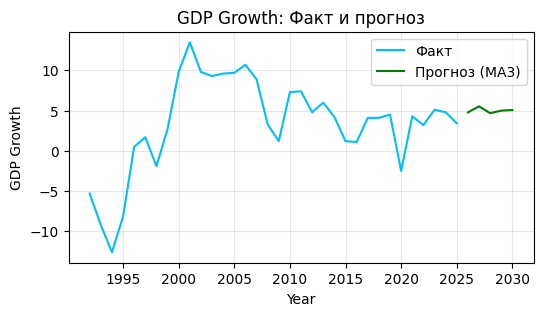

In [ ]:
vars = [
   
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',          
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]
X_new = df[vars].copy()

for year in future_years:
    ma3 = X_new.tail(3).mean()
    X_new.loc[year] = ma3

X_fut = X_new.loc[future_years].copy()
X_fut["const"] = 1
X_fut = X_fut[model.model.exog_names]
forecast_ma = model.predict(X_fut)

plt.figure(figsize=(6, 3))
x_fact = df["Date"]
y_fact = df["GDP Growth"]

plt.plot(x_fact, y_fact, color="deepskyblue", label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, color="green", label="Прогноз (MA3)")
plt.grid(alpha=0.3)
plt.title("GDP Growth: Факт и прогноз")
plt.xlabel("Year")
plt.ylabel("GDP Growth")
plt.legend()
plt.show()

вариации OLS моделей с разными регрессорами, которые мы проверяли:

In [15]:
y = df["Consumer Price Inflation"]

X = df[[

    "Gross National Savings",
    "Government Debt",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "GDP Growth",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",
    "Fiscal Rule",
    "Expenditure",
    "Politic leader"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Consumer Price Inflation   R-squared:                       0.860
Model:                                  OLS   Adj. R-squared:                  0.644
Method:                       Least Squares   F-statistic:                     3.981
Date:                      Mon, 01 Dec 2025   Prob (F-statistic):            0.00691
Time:                              17:09:28   Log-Likelihood:                -50.852
No. Observations:                        34   AIC:                             143.7
Df Residuals:                            13   BIC:                             175.8
Df Model:                                20                                         
Covariance Type:                  nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          -14.0269     10.978     -1.278      0.224     -37.744       9.690
Gross National Savings                           0.0002      0.000      1.663      0.120   -6.57e-05       0.001
Government Debt                                 -0.3426      0.220     -1.556      0.144      -0.818       0.133
Natural Gas Production                          -0.5961      0.306     -1.950      0.073      -1.257       0.064
Iron Ore Production                           -6.84e-08   9.38e-08     -0.729      0.479   -2.71e-07    1.34e-07
Inbound Foreign Direct Investment                0.0002      0.000      1.024      0.324      -0.000       0.001
Natural Population Growth                     1.179e-05   2.03e-05      0.581      0.571    -3.2e-05    5.56e-05
Government Budget Revenues                      -0.0002      0.000     -1.713      0.110      -0.001    5.98e-05
Coal Imports                                  1.203e-05   1.21e-05      0.994      0.338   -1.41e-05    3.82e-05
Share of Military Expenditures in the Budget     1.5823      1.365      1.159      0.267      -1.366       4.531
Foreign Reserves                              5.231e-05   9.88e-05      0.530      0.605      -0.000       0.000
GDP Growth                                       0.0023      0.184      0.012      0.990      -0.395       0.400
Average Annual Exchange Rate to USD              0.0511      0.018      2.910      0.012       0.013       0.089
Fuel Exports, % of Merchandise Exports          -0.1632      0.118     -1.386      0.189      -0.418       0.091
Coal Exports                                  1.323e-07      1e-07      1.319      0.210   -8.44e-08    3.49e-07
Electricity Exports                             -0.3843      0.287     -1.341      0.203      -1.004       0.235
OIL Production                                   0.0005      0.004      0.116      0.910      -0.008       0.009
Oil Prices                                       0.1185      0.085      1.391      0.187      -0.065       0.302
Fiscal Rule                                      5.6319      5.168      1.090      0.296      -5.533      16.797
Expenditure                                      0.8373      0.353      2.369      0.034       0.074       1.601
Politic leader                                  -8.2555      4.358     -1.894      0.081     -17.671       1.160
==============================================================================
Omnibus:                        1.222   Durbin-Watson:                   2.696
Prob(Omnibus):                  0.543   Jarque-Bera (JB):                0.423
Skew:                          -0.201   Prob(JB):                   

In [16]:
Х_cols = [
    "Average Annual Exchange Rate to USD",
    "Fiscal Rule",
    "Politic leader",
    "Share of Military Expenditures in the Budget",
    "Coal Imports",
    "Inbound Foreign Direct Investment",
    "Foreign Reserves",
    "Natural Population Growth"
]

y = df["GDP Growth"]

X = df[Х_cols]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP Growth   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     5.878
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           0.000286
Time:                        17:10:14   Log-Likelihood:                -90.020
No. Observations:                  34   AIC:                             198.0
Df Residuals:                      25   BIC:                             211.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           10.0333      8.239      1.218      0.235      -6.934      27.001
Average Annual Exchange Rate to USD              0.0066      0.018      0.366      0.717      -0.030       0.044
Fiscal Rule                                      2.4809      3.723      0.666      0.511      -5.187      10.148
Politic leader                                  -0.6831      2.987     -0.229      0.821      -6.834       5.468
Share of Military Expenditures in the Budget     1.5186      1.226      1.239      0.227      -1.005       4.043
Coal Imports                                 -3.493e-06   9.34e-06     -0.374      0.712   -2.27e-05    1.58e-05
Inbound Foreign Direct Investment                0.0004      0.000      1.549      0.134      -0.000       0.001
Foreign Reserves                                 0.0003      0.000      1.912      0.067   -2.03e-05       0.001
Natural Population Growth                       -0.0001   2.43e-05     -4.346      0.000      -0.000   -5.55e-05
==============================================================================
Omnibus:                        2.259   Durbin-Watson:                   1.179
Prob(Omnibus):                  0.323   Jarque-Bera (JB):                1.966
Skew:                          -0.570   Prob(JB):                        0.374
Kurtosis:                       2.702   Cond. No.                     2.95e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.95e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
y = df["Government Debt"]

X = df[[
    "Gross National Savings",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "GDP Growth",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",
    "Fiscal Rule",
    "Expenditure",
    "Consumer Price Inflation",
    "Politic leader"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Government Debt   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     9.808
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           6.69e-05
Time:                        17:10:36   Log-Likelihood:                -55.788
No. Observations:                  34   AIC:                             153.6
Df Residuals:                      13   BIC:                             185.6
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          -11.0304     13.115     -0.841      0.416     -39.364      17.303
Gross National Savings                           0.0004      0.000      2.771      0.016    8.15e-05       0.001
Natural Gas Production                          -0.8826      0.319     -2.769      0.016      -1.571      -0.194
Iron Ore Production                           6.952e-08   1.09e-07      0.638      0.535   -1.66e-07    3.05e-07
Inbound Foreign Direct Investment               -0.0003      0.000     -1.176      0.261      -0.001       0.000
Natural Population Growth                    -2.639e-06   2.37e-05     -0.111      0.913   -5.39e-05    4.86e-05
Government Budget Revenues                      -0.0001      0.000     -0.601      0.558      -0.000       0.000
Coal Imports                                  1.201e-05   1.41e-05      0.850      0.411   -1.85e-05    4.25e-05
Share of Military Expenditures in the Budget     3.6596      1.310      2.793      0.015       0.829       6.491
Foreign Reserves                               9.45e-05      0.000      0.841      0.416      -0.000       0.000
GDP Growth                                       0.0678      0.212      0.320      0.754      -0.390       0.526
Average Annual Exchange Rate to USD              0.0563      0.021      2.692      0.018       0.011       0.101
Fuel Exports, % of Merchandise Exports          -0.3040      0.119     -2.554      0.024      -0.561      -0.047
Coal Exports                                   1.21e-08   1.23e-07      0.098      0.923   -2.55e-07    2.79e-07
Electricity Exports                             -0.6756      0.300     -2.253      0.042      -1.323      -0.028
OIL Production                                   0.0069      0.004      1.624      0.128      -0.002       0.016
Oil Prices                                      -0.0213      0.105     -0.202      0.843      -0.249       0.206
Fiscal Rule                                      7.8072      5.855      1.333      0.205      -4.841      20.456
Expenditure                                      0.9617      0.410      2.347      0.035       0.076       1.847
Consumer Price Inflation                        -0.4581      0.294     -1.556      0.144      -1.094       0.178
Politic leader                                 -11.7376      4.669     -2.514      0.026     -21.825      -1.650
==============================================================================
Omnibus:                        4.871   Durbin-Watson:                   2.852
Prob(Omnibus):                  0.088   Jarque-Bera (JB):                3.548
Skew:                           0.761   Prob(JB):                        0.170
Kurtosis:                       3.437   Cond. No.      

In [18]:
y = df["Government Debt"]

X = df[[
    "Average Annual Exchange Rate to USD",
    "Fiscal Rule",
    "Politic leader",
    "Share of Military Expenditures in the Budget",
    "Coal Imports",
    "Inbound Foreign Direct Investment",
    "Foreign Reserves",
    "Date"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Government Debt   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     14.14
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.54e-07
Time:                        17:12:57   Log-Likelihood:                -73.964
No. Observations:                  34   AIC:                             165.9
Df Residuals:                      25   BIC:                             179.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                         -214.6951    273.167     -0.786      0.439    -777.292     347.902
Average Annual Exchange Rate to USD              0.0290      0.011      2.614      0.015       0.006       0.052
Fiscal Rule                                     -1.3295      2.684     -0.495      0.625      -6.857       4.199
Politic leader                                   0.4003      2.032      0.197      0.845      -3.784       4.584
Share of Military Expenditures in the Budget    -0.0027      0.788     -0.003      0.997      -1.627       1.621
Coal Imports                                 -1.382e-05   4.05e-06     -3.413      0.002   -2.22e-05   -5.48e-06
Inbound Foreign Direct Investment               -0.0004      0.000     -2.303      0.030      -0.001   -3.88e-05
Foreign Reserves                                -0.0001    9.9e-05     -1.186      0.247      -0.000    8.65e-05
Date                                             0.1149      0.137      0.838      0.410      -0.168       0.398
==============================================================================
Omnibus:                       11.441   Durbin-Watson:                   2.245
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               14.066
Skew:                           0.869   Prob(JB):                     0.000882
Kurtosis:                       5.628   Cond. No.                     1.13e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
y = df["Government Budget Revenues"]  

X = df[[
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Government Budget Revenues   R-squared:                       0.988
Model:                                    OLS   Adj. R-squared:                  0.969
Method:                         Least Squares   F-statistic:                     52.82
Date:                        Mon, 01 Dec 2025   Prob (F-statistic):           2.47e-09
Time:                                17:13:16   Log-Likelihood:                -307.07
No. Observations:                          34   AIC:                             656.1
Df Residuals:                              13   BIC:                             688.2
Df Model:                                  20                                         
Covariance Type:                    nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                        -1.334e+04   2.15e+04     -0.620      0.546   -5.98e+04    3.31e+04
Gross National Savings                           0.0971      0.271      0.358      0.726      -0.489       0.684
Government Debt                               -266.4938    443.456     -0.601      0.558   -1224.522     691.534
Natural Gas Production                          38.1608    651.380      0.059      0.954   -1369.061    1445.383
Iron Ore Production                             -0.0004      0.000     -2.873      0.013      -0.001      -0.000
Inbound Foreign Direct Investment                0.3826      0.414      0.924      0.373      -0.512       1.278
Natural Population Growth                       -0.0238      0.038     -0.627      0.542      -0.106       0.058
Coal Imports                                    -0.0290      0.022     -1.313      0.212      -0.077       0.019
Share of Military Expenditures in the Budget    26.4569   2686.830      0.010      0.992   -5778.086    5830.999
Foreign Reserves                                 0.0635      0.186      0.341      0.738      -0.339       0.466
GDP Growth                                    -467.7218    319.795     -1.463      0.167   -1158.598     223.154
Average Annual Exchange Rate to USD            103.4239     31.053      3.331      0.005      36.339     170.509
Fuel Exports, % of Merchandise Exports        -173.9980    231.456     -0.752      0.466    -674.028     326.032
Coal Exports                                  9.257e-05      0.000      0.466      0.649      -0.000       0.001
Electricity Exports                            671.6202    542.052      1.239      0.237    -499.411    1842.652
OIL Production                                   3.9695      7.512      0.528      0.606     -12.258      20.197
Oil Prices                                     526.4326     89.174      5.903      0.000     333.784     719.081
Fiscal Rule                                  -1.552e+04   9157.766     -1.694      0.114   -3.53e+04    4266.590
Expenditure                                    977.9200    744.672      1.313      0.212    -630.847    2586.687
Consumer Price Inflation                      -804.2403    469.528     -1.713      0.110   -1818.594     210.113
Politic leader                                 596.8079   9225.405      0.065      0.949   -1.93e+04    2.05e+04
==============================================================================
Omnibus:                        1.477   Durbin-Watson:                   2.360
Prob(Omnibus):                  0.478   Jarque-Bera (JB):                0.631
Skew:                           0.283   Prob(J

In [21]:
y = df["Government Budget Revenues"] 

X = df[[
    'Gross National Savings',
    'Foreign Reserves',
    'Natural Gas Production',
    'Iron Ore Production',
    'OIL Production',
    'Date',
    'Oil Prices',
    'Fuel Exports, % of Merchandise Exports'
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Government Budget Revenues   R-squared:                       0.955
Model:                                    OLS   Adj. R-squared:                  0.941
Method:                         Least Squares   F-statistic:                     66.36
Date:                        Mon, 01 Dec 2025   Prob (F-statistic):           6.46e-15
Time:                                17:13:44   Log-Likelihood:                -329.32
No. Observations:                          34   AIC:                             676.6
Df Residuals:                              25   BIC:                             690.4
Df Model:                                   8                                         
Covariance Type:                    nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                  -7.355e+05   1.31e+06     -0.563      0.579   -3.43e+06    1.96e+06
Gross National Savings                     0.3590      0.100      3.595      0.001       0.153       0.565
Foreign Reserves                           0.6384      0.159      4.009      0.000       0.310       0.966
Natural Gas Production                   -24.5983    282.052     -0.087      0.931    -605.494     556.298
Iron Ore Production                       -0.0002      0.000     -2.354      0.027      -0.000   -2.97e-05
OIL Production                           -13.6279     16.306     -0.836      0.411     -47.211      19.955
Date                                     370.1147    655.907      0.564      0.578    -980.750    1720.980
Oil Prices                               311.5958     56.015      5.563      0.000     196.232     426.960
Fuel Exports, % of Merchandise Exports    44.8071    167.362      0.268      0.791    -299.881     389.495
==============================================================================
Omnibus:                       10.757   Durbin-Watson:                   2.424
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               22.071
Skew:                          -0.434   Prob(JB):                     1.61e-05
Kurtosis:                       6.850   Cond. No.                     6.11e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.11e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""